DATA AUGMENTATION E MIGLIORAMENTO DELLA GENERALIZZAZIONE

La data augmentation permette di trasformare un piccolo dataset di partenza in una fonte inesauribile di conosceza, inventando dati, ma non barando, ma imparando meglio dai dati.

ARTE DI MOLTIPLICARE LA CONOSCENZA
Insieme di tecniche che ci permettono di 'gonfiare' il dataset originale.
Esempio ho la foto di un gatto, la ruoto, la rimpicciolisco, per il dataset sono dati diversi, ma per la rete è importante.
Voglioamo che il nostro modello sia come un amico che mi riconosce anche se porto un cappello o occhiali nuovi (INVARIANZA).
Inoltre la Data Augmentation agisce come un regolarizzatore naturale, simile al dropout, riducendo la memorizzazione
Se il dropaout spegne i neurono l'augmentatio sporca gli input.
Prepariamo la rete a scenari che non ha mai visto, ma che sono plausibili.

Come decidiamo quali trasformazioni applicare senza rovinare il dato?

TRASFORMAZIONI DETERMINISTICHE
Si tratta di modifiche fisse applicate a ogni campione, utili per correggere bias strutturali nel modo in cui i dati sono stati raccolti.

TRASFORMAZIONI STOCASTICHE
L'introduzione di casualità garantisce che la rete veda campioni leggermente diversi a ogni epoca, rendendo l'addestramento dinamico.

CONSERVAZIONE DELLE ETICHETTE
L'operazione fondamentale è applicare una funzione che alteri i valori numerici lascinado invariato il valore target desiderato.

La funzione f deve modificare l'input x senza mai cambiare l'etichetta target
Se trasformo un gatto in qualcosa che sembra un cane, insegno alla rete a sbagliare.

Sulle tabelle (sui dati numerici) non possiamo fare zoom (per aumentare i dati), la strategia principale diventa aggiungere rumore (noise injection), non servono dettagli perfetti, serve capire la tendenza generale. Costringiamo la rete a concentrarsi sulla struttura vera dei dati, non sui 'decimali' poco significative.
Questa tecnica consiste nell'aggiungere piccole perturbazioni ai valori delle feature per costringere la rete a imparare pattern robusti anzichè coordinate esatte nello spazio multidimensionale

Tecniche:
- Noise injection: aggiunta di valori casuali tratti da una distribuzione statistica definita sopra i valori originali
- Feature Shuffiling: rimescola i valori di una colonna specifica tra diversi record per rompere correlazioni accidentali
- Dropout di input: azzerare casualmente alcune celle della tabella durante l'addestramento per simulare dati mancanti.
- Smote: generazione di campioni sintetici interpolando tra i vicini più prossimi nello spazio delle feature. E' come unire i puntini tra due campioni esistenti, per crearne dei nuovi.

Il rumore può essere additivo, moltiplicativo, gaussiano.
La media è zero, non vogliamo spostare i data ma solo farli vibrare intorno alla loro posizione originale.

Con Numpy (non servono librerie particolari) dobbiamo generare un 'tappeto' di disturbo, una matrice con la stessa forma del dataset di partenza ma con dei valori scalati. il passaggio critico è decidiere l'intensità, se sigma è troppo basso la rete non si accorge nemmeno del disturbo, se sigma è troppo alto distruggiamo l'informazione di partenza.

Per gestire una simulazione seria abbiamo bisogno di 4 elementi:
- Media, solitamente impostata e zero
- Deviazione Standard: definisce l'ampiezza di disturo
- Riproduciblità usa sempre il seed casuale.
- Broadcasting: tacnica di calcolo che permette di applicare il disturbo a interi matrice di dati in modo efficiente.



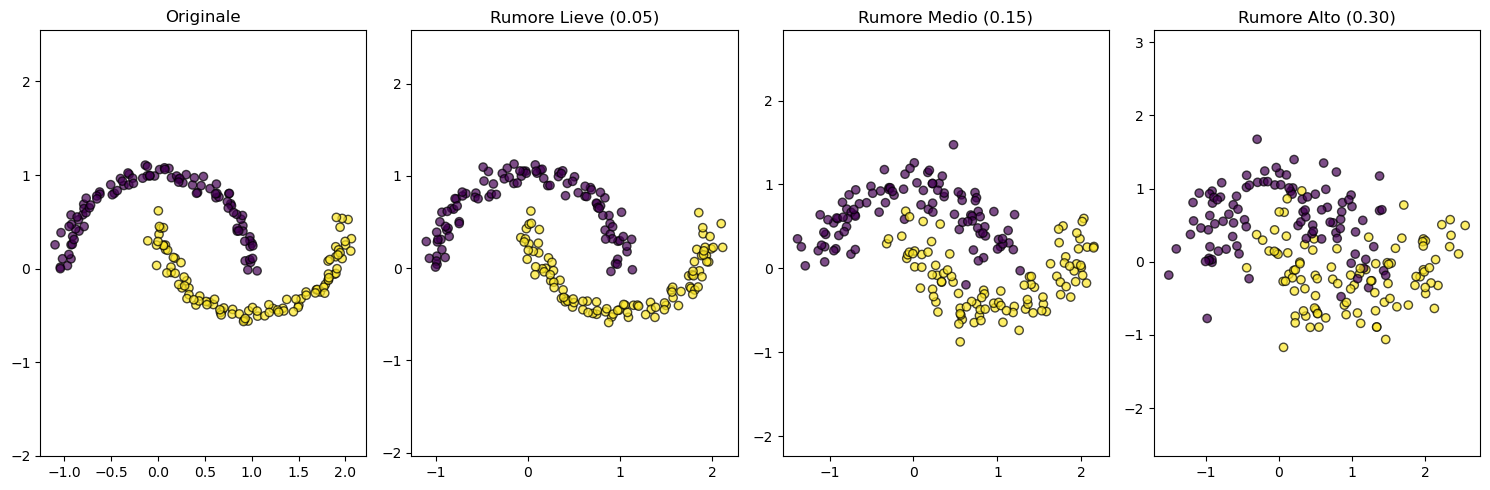

Analisi: Notate come all'aumentare di sigma, i punti 'esplorano' lo spazio circostante.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# 1. PREPARAZIONE DEL DATASET ORIGINALE
# Generiamo un dataset non lineare (due mezzelune)
X_orig, y_orig = make_moons(n_samples=200, noise=0.05, random_state=42)

def inject_gaussian_noise(data, sigma=0.1):
    """
    Applica rumore gaussiano additivo al dataset.
    Parametri:
    - data: il tensore o array originale
    - sigma: deviazione standard del rumore (intensità)
    """
    # Generiamo il rumore con la stessa forma del dataset originale
    # Media = 0, Deviazione Standard = sigma
    noise = np.random.normal(loc=0.0, scale=sigma, size=data.shape)
    
    # Restituiamo il dato "aumentato"
    return data + noise

# 2. GENERAZIONE DATI AUMENTATI
# Creiamo tre versioni con intensità di rumore crescente
X_noise_low = inject_gaussian_noise(X_orig, sigma=0.05)
X_noise_med = inject_gaussian_noise(X_orig, sigma=0.15)
X_noise_high = inject_gaussian_noise(X_orig, sigma=0.30)

# 3. VISUALIZZAZIONE COMPARATIVA
plt.figure(figsize=(15, 5))

titles = ['Originale', 'Rumore Lieve (0.05)', 'Rumore Medio (0.15)', 'Rumore Alto (0.30)']
datasets = [X_orig, X_noise_low, X_noise_med, X_noise_high]

for i, ds in enumerate(datasets):
    plt.subplot(1, 4, i+1)
    plt.scatter(ds[:, 0], ds[:, 1], c=y_orig, cmap='viridis', edgecolors='k', alpha=0.7)
    plt.title(titles[i])
    plt.axis('equal')

plt.tight_layout()
plt.show()

print("Analisi: Notate come all'aumentare di sigma, i punti 'esplorano' lo spazio circostante.")

con rumore lieve è un poco più dati ma contenuta, com edia ed alto si aggiunge molta dispersione di dati, con 0.3 diventa difficile da valutare.